# Question 3 Random Walk Task

{'A': 0.13008697069572794, 'B': 0.3068304731549259, 'C': 0.5369566229823367, 'D': 0.728101387432365, 'E': 0.8798854701651839, 'left_terminal': 0.0, 'right_terminal': 0.0}


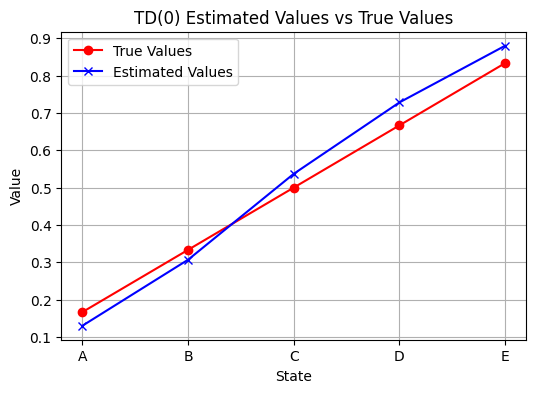

In [43]:
import numpy as np
import matplotlib.pyplot as plt

class RandomWalk:
    def __init__(self):
        """Initialize the 5-state Random Walk MRP."""
        self.states = ['A', 'B', 'C', 'D', 'E']
        self.terminal_states = ['left_terminal', 'right_terminal']

    def reset(self):
        """Reset the environment to the start state (C)."""
        self.state = 'C'
        return self.state
    
    def step(self, action):
        action = np.random.choice([-1, 1])
        idx = self.states.index(self.state)
        next_idx = idx + action

        if next_idx < 0:
            return 'left_terminal', 0, True
        elif next_idx >= len(self.states):
            return 'right_terminal', 1, True

        self.state = self.states[next_idx]
        return self.state, 0, False

class TDLearner:
    def __init__(self, alpha=0.1):
        """Initialize the TD(0) learning algorithm."""
        self.alpha = alpha
    
    def update(self, state, reward, next_state):
        gamma = 1.0
        
        if not hasattr(self, 'V'):
            self.V = {s: 0.5 for s in ['A', 'B', 'C', 'D', 'E']}
            self.V['left_terminal'] = 0.0
            self.V['right_terminal'] = 0.0

        if state not in ['left_terminal', 'right_terminal']:
            self.V[state] += self.alpha * (reward + gamma * self.V[next_state] - self.V[state])

def run_experiment(num_episodes=1000):
    """Run the Random Walk experiment with TD(0)."""
    env = RandomWalk()
    agent = TDLearner(alpha=0.1)
    
    for episode in range(num_episodes):
        state = env.reset()
        done = False
        while not done:
            action = np.random.choice([-1, 1])
            next_state, reward, done = env.step(action)
            agent.update(state, reward, next_state)
            state = next_state
    print(agent.V)
    return agent.V

def plot_results(estimated_values):
    """Plot estimated values against true values."""
    states = ['A', 'B', 'C', 'D', 'E']
    true_values = [1/6, 2/6, 3/6, 4/6, 5/6]
    
    estimated = [estimated_values['A'], estimated_values['B'], estimated_values['C'], estimated_values['D'], estimated_values['E']]
    
    plt.figure(figsize=(6, 4))
    plt.plot(states, true_values, 'ro-', label='True Values')
    plt.plot(states, estimated, 'bx-', label='Estimated Values')
    plt.xlabel('State')
    plt.ylabel('Value')
    plt.title('TD(0) Estimated Values vs True Values')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    estimated_values = run_experiment()
    plot_results(estimated_values)

# Question 4 Windy Gridworld Domain

In [44]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [45]:
class WindyGridWorld(object):
    def __init__(self, enable_king_move=False, enable_no_move=False):
        # define the grid space
        self.grid = np.zeros((7, 10))

        # define the state space
        self.state_space = [[r, c] for r, c in zip(np.where(self.grid == 0.0)[0],
                                                   np.where(self.grid == 0.0)[1])]

        # define the start state
        self.start_state = [3, 0]

        # define the goal state
        self.goal_state = [3, 7]

        # define the wind
        self.wind = np.array([0, 0, 0, 1, 1, 1, 2, 2, 1, 0], dtype=int)

        # # define the action space
        self.action_space = {
            "up": np.array([-1, 0]),
            "down": np.array([1, 0]),
            "left": np.array([0, -1]),
            "right": np.array([0, 1])
        }
        
        # Enable King's moves (Comment out the above action space to create a new one for King's moves)
        # if enable_king_move:
        #     if enable_no_move:
        #         self.action_space = {
        #             "up":         np.array([-1,  0]),
        #             "down":       np.array([ 1,  0]),
        #             "left":       np.array([ 0, -1]),
        #             "right":      np.array([ 0,  1]),
        #             "up_left":    np.array([-1, -1]),
        #             "up_right":   np.array([-1,  1]),
        #             "down_left":  np.array([ 1, -1]),
        #             "down_right": np.array([ 1,  1]),
        #             "stay":       np.array([ 0,  0])
        #         }
        #     else:
        #         self.action_space = {
        #             "up":         np.array([-1,  0]),
        #             "down":       np.array([ 1,  0]),
        #             "left":       np.array([ 0, -1]),
        #             "right":      np.array([ 0,  1]),
        #             "up_left":    np.array([-1, -1]),
        #             "up_right":   np.array([-1,  1]),
        #             "down_left":  np.array([ 1, -1]),
        #             "down_right": np.array([ 1,  1])
        #         }
        # else:
        #     self.action_space = {
        #         "up":    np.array([-1,  0]),
        #         "down":  np.array([ 1,  0]),
        #         "left":  np.array([ 0, -1]),
        #         "right": np.array([ 0,  1])
        #     }
                
        # track the current state, time step, and action
        self.state = None
        self.t = None
        self.act = None

    def reset(self):
        # reset the agent to the start state
        self.state = self.start_state
        # reset the time step tracker
        self.t = 0
        # reset the action tracker
        self.act = None
        # reset the terminal flag
        terminated = False
        return self.state, terminated

    def step(self, act):
        row, col = self.state

        delta = self.action_space[act]

        if self.wind[col] != 0:
            stochastic_wind = self.wind[col] + np.random.choice([-1, 0, 1])
        else:
            stochastic_wind = self.wind[col]

        new_row = row + delta[0] - stochastic_wind
        new_col = col + delta[1]

        new_row = np.clip(new_row, 0, self.grid.shape[0] - 1)
        new_col = np.clip(new_col, 0, self.grid.shape[1] - 1)

        self.state = [new_row, new_col]

        if self.state == self.goal_state:
            reward = 0
            terminated = True
            goal_state = self.state  # save before reset
            self.reset()
            return goal_state, reward, terminated
        else:
            reward = -1
            terminated = False

        return self.state, reward, terminated

    def render(self):
        # plot the agent and the goal
        # agent = 1
        # goal = 2
        plot_arr = self.grid.copy()
        plot_arr[self.state[0], self.state[1]] = 1.0
        plot_arr[self.goal_state[0], self.goal_state[1]] = 2.0
        plt.clf()
        fig, arr = plt.subplots(1, 1)
        arr.set_title(f"state={self.state}, act={self.act}")
        arr.imshow(plot_arr)
        plt.show(block=False)
        plt.pause(1)
        plt.close(fig)


In [46]:
class OnPolicyMC(object):
    def __init__(self, env, epsilon, gamma, timeout):
        self.epsilon = epsilon
        self.gamma = gamma
        self.env = env
        self.timeout = timeout

        self.actions = list(self.env.action_space.keys())
        self.action_num = len(self.actions)
        self.Q = {}
        self.returns_sum = {}
        self.returns_count = {}
        self.pi = {}

    def behavior_policy(self, state):
        state = tuple(state)
        if np.random.random() < self.epsilon or state not in self.pi:
            return self.actions[np.random.randint(self.action_num)]
        else:
            return self.actions[self.pi[state]]

    def update(self, episode):
        states = [step[0] for step in episode]
        actions = [step[1] for step in episode]
        rewards = [step[2] for step in episode]

        G = 0
        for t in reversed(range(len(episode))):
            G = rewards[t] + self.gamma * G
            state = states[t]
            action = actions[t]
            state_action_pairs = list(zip(states[0:t], actions[0:t]))
            if (state, action) not in state_action_pairs:
                if (state, action) not in self.returns_sum:
                    self.returns_sum[state, action] = 0
                    self.returns_count[state, action] = 0
                self.returns_sum[state, action] += G
                self.returns_count[state, action] += 1
                self.Q[state, action] = self.returns_sum[state, action] / self.returns_count[state, action]

                q_values = [self.Q.get((state, a), 0) for a in self.actions]
                self.pi[state] = np.argmax(q_values)

    def rollout(self):
        state, _ = self.env.reset()
        episode = []
        for t in range(500):
            a = self.behavior_policy(state)
            s_prime, r, terminated = self.env.step(a)
            episode.append((tuple(state), a, r))
            state = s_prime
            if terminated:
                break
        self.update(episode)
        return t + 1

    def run(self):
        steps = np.zeros(8000)
        total_steps = 0
        ep = 0
        while total_steps < 8000:
            t = self.rollout()
            for i in range(total_steps, min(total_steps + t, 8000)):
                steps[i] = ep
            total_steps += t
            ep += 1
        return steps
    

In [47]:
class SARSA(object):
    def __init__(self, env, alpha, epsilon, gamma, timeout):
        # define the parameters
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma

        # environment
        self.env = env

        # define the Q value table
        self.state_num = len(self.env.state_space)
        self.action_num = len(self.env.action_space.keys())
        self.Q = np.zeros((self.state_num, self.action_num))

        # define the timeout
        self.timeout = timeout

    def behavior_policy(self, state):
        state_idx = self.env.state_space.index(state)
        actions = list(self.env.action_space.keys())
        if np.random.random() < self.epsilon:
            act = np.random.choice(actions)
        else:
            act = actions[np.argmax(self.Q[state_idx])]
        return act

    def update(self, s, a, r, s_prime, a_prime):
        s_idx = self.env.state_space.index(s)
        s_prime_idx = self.env.state_space.index(s_prime)
        actions = list(self.env.action_space.keys())
        a = actions.index(a)
        a_prime = actions.index(a_prime)
        self.Q[s_idx, a] = self.Q[s_idx, a] + self.alpha * (r + self.gamma * self.Q[s_prime_idx, a_prime] - self.Q[s_idx, a])

    def rollout(self):
        state, _ = self.env.reset()
        act = self.behavior_policy(state)
        for t in range(self.timeout):
            s_prime, r, terminated = self.env.step(act)
            a_prime = self.behavior_policy(s_prime)
            self.update(state, act, r, s_prime, a_prime)
            state = s_prime
            act = a_prime
            if terminated:
                break
        return t + 1

    def run(self):
        steps = np.zeros(8000)
        total_steps = 0
        ep = 0
        while total_steps < 8000:
            t = self.rollout()
            for i in range(total_steps, min(total_steps + t, 8000)):
                steps[i] = ep
            total_steps += t
            ep += 1
        return steps

In [48]:
class ExpectedSARSA(object):
    def __init__(self, env, alpha, epsilon, gamma, timeout):
        # define the parameters
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma

        # environment
        self.env = env

        # define the Q value table
        self.state_num = len(self.env.state_space)
        self.action_num = len(self.env.action_space.keys())
        self.Q = np.zeros((self.state_num, self.action_num))

        # define the timeout
        self.timeout = timeout

    def behavior_policy(self, state):
        state_idx = self.env.state_space.index(state)
        actions = list(self.env.action_space.keys())
        if np.random.random() < self.epsilon:
            act_idx = np.random.randint(self.action_num)
        else:
            act_idx = int(np.argmax(self.Q[state_idx]))
        return actions[act_idx]

    def update(self, s, a, r, s_prime, a_prime):
        s = self.env.state_space.index(s)
        s_prime = self.env.state_space.index(s_prime)
        actions = list(self.env.action_space.keys())
        a_idx = actions.index(a)
        
        probs = np.ones(self.action_num) * (self.epsilon / self.action_num)
        probs[np.argmax(self.Q[s_prime])] += (1 - self.epsilon)
        
        self.Q[s, a_idx] += self.alpha * (r + self.gamma * np.dot(probs, self.Q[s_prime]) - self.Q[s, a_idx])

    def rollout(self):
        state, _ = self.env.reset()
        for t in range(self.timeout):
            a = self.behavior_policy(state)
            s_prime, r, terminated = self.env.step(a)
            a_prime = self.behavior_policy(s_prime)
            self.update(state, a, r, s_prime, a_prime)
            state = s_prime
            if terminated:
                break
        return t + 1
    
    def run(self):
        steps = np.zeros(8000)
        total_steps = 0
        ep = 0
        while total_steps < 8000:
            t = self.rollout()
            for i in range(total_steps, min(total_steps + t, 8000)):
                steps[i] = ep
            total_steps += t
            ep += 1
        return steps

In [49]:
class QLearning(object):
    def __init__(self, env, alpha, epsilon, gamma, timeout):
        # define the parameters
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma

        # environment
        self.env = env

        # define the Q value table
        self.state_num = len(self.env.state_space)
        self.action_num = len(self.env.action_space.keys())
        self.Q = np.zeros((self.state_num, self.action_num))

        # define the timeout
        self.timeout = timeout

    def behavior_policy(self, state):
        state_idx = self.env.state_space.index(state)
        actions = list(self.env.action_space.keys())
        if np.random.random() < self.epsilon:
            act = np.random.choice(actions)
        else:
            act = actions[np.argmax(self.Q[state_idx])]
        return act

    def update(self, s, a, r, s_prime):
        s = self.env.state_space.index(s)
        s_prime = self.env.state_space.index(s_prime)
        actions = list(self.env.action_space.keys())
        a = actions.index(a)
        self.Q[s,a] = self.Q[s,a] + self.alpha * (r + self.gamma * np.max(self.Q[s_prime]) - self.Q[s,a])

    def rollout(self):
        state, _ = self.env.reset()
        for t in range(self.timeout):
            a = self.behavior_policy(state)
            s_prime, r, terminated = self.env.step(a)
            self.update(state, a, r, s_prime)
            state = s_prime
            if terminated:
                break
        return t + 1

    def run(self):
        steps = np.zeros(8000)
        total_steps = 0
        ep = 0
        while total_steps < 8000:
            t = self.rollout()
            for i in range(total_steps, min(total_steps + t, 8000)):
                steps[i] = ep
            total_steps += t
            ep += 1
        return steps

In [50]:
def plot_curves(arr_list, legend_list, color_list, ylabel):
    """
    Args:
        arr_list (list): list of results arrays to plot
        legend_list (list): list of legends corresponding to each result array
        color_list (list): list of color corresponding to each result array
        ylabel (string): label of the Y axis

    Make sure the elements in the arr_list, legend_list, and color_list are associated with each other correctly.
    Do not forget to change the ylabel for different plots.
    """
    # Clear the current figure
    plt.clf()
    fig, ax = plt.subplots(figsize=(12, 8))

    # Set labels
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Time Steps")

    # Plot results
    h_list = []
    for arr, legend, color in zip(arr_list, legend_list, color_list):
        # Compute the mean and standard error while ignoring NaN values
        mean_arr = np.nanmean(arr, axis=0)
        arr_err = np.nanstd(arr, axis=0) / np.sqrt(np.sum(~np.isnan(arr), axis=0))
        
        # Plot the mean
        h, = ax.plot(range(len(mean_arr)), mean_arr, color=color, label=legend)
        
        # Plot the confidence band
        arr_err = 1.96 * arr_err  # 95% confidence interval
        ax.fill_between(range(len(mean_arr)),
                        mean_arr - arr_err,
                        mean_arr + arr_err,
                        alpha=0.3, color=color)
        # Save the plot handle
        h_list.append(h)

    # Set the title (adjust as needed)
    ax.set_title("Windy Gridworld Results")
    ax.legend(handles=h_list)
    plt.show()

In [51]:
def run_on_policy_td_control(run_num, timeout):
    
    enable_king_move_actions = True
    enable_no_move_actions = True
    
    # create the environment
    env = WindyGridWorld(enable_king_move=enable_king_move_actions, enable_no_move=enable_no_move_actions)

    # parameters
    epsilon = 0.1
    alpha = 0.5
    gamma = 1.0

    # create the expected SARSA
    expected_sarsa_results_list = []
    for _ in range(run_num):
        controller_expected_sarsa = ExpectedSARSA(env, alpha, epsilon, gamma, timeout)
        episodes = controller_expected_sarsa.run()
        expected_sarsa_results_list.append(episodes[0:8000])
        
    # create the SARSA
    sarsa_results_list = []
    for _ in range(run_num):
        controller_sarsa = SARSA(env, alpha, epsilon, gamma, timeout)
        episodes = controller_sarsa.run()
        sarsa_results_list.append(episodes[0:8000])

    # create the Q learning
    q_learning_results_list = []
    for _ in range(run_num):
        controller_q_learning = QLearning(env, alpha, epsilon, gamma, timeout)
        episodes = controller_q_learning.run()
        q_learning_results_list.append(episodes[0:8000])

    # create the MC
    mc_results_list = []
    for _ in range(run_num):
        controller_mc = OnPolicyMC(env, epsilon, gamma, timeout)
        episodes = controller_mc.run()
        mc_results_list.append(episodes[0:8000])
    
    sarsa_array = np.array(sarsa_results_list)
    expected_sarsa_array = np.array(expected_sarsa_results_list)
    q_learning_array = np.array(q_learning_results_list)
    mc_array = np.array(mc_results_list)
    
    # Plot the results
    plot_curves(
        [sarsa_array, expected_sarsa_array, q_learning_array, mc_array],
        ['SARSA', 'Expected SARSA', 'Q-learning', 'MC'],
        ['r', 'b', 'g', 'm'],
        "Episodes"
    )

<Figure size 640x480 with 0 Axes>

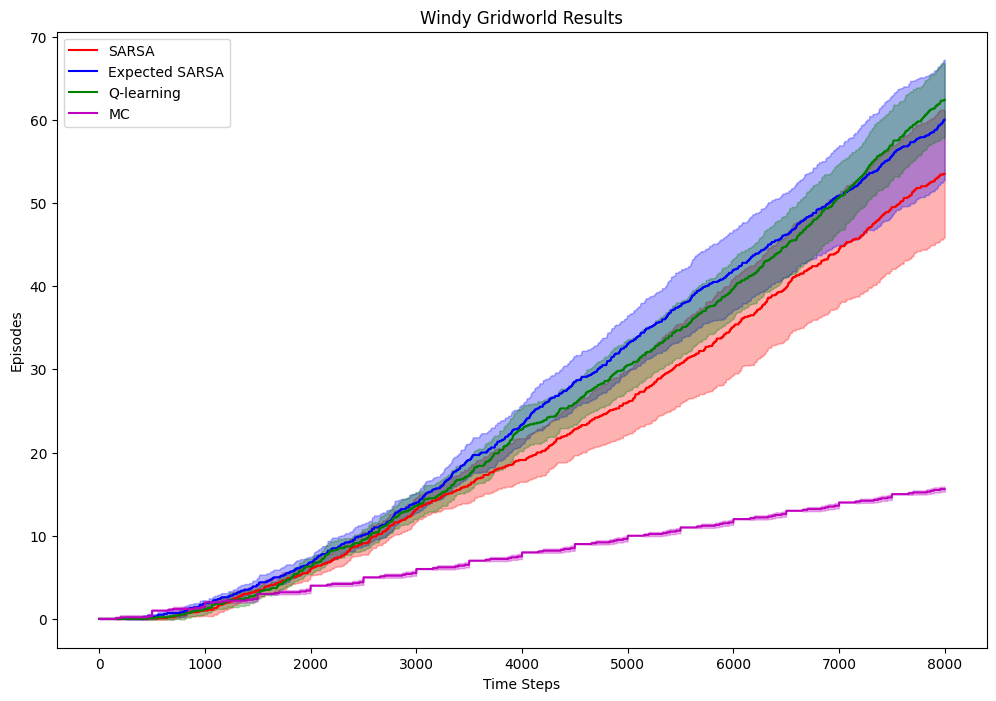

In [52]:
if __name__ == "__main__":
    # set randomness
    np.random.seed(1234)
    random.seed(1234)

    # trial number
    trial_num = 10
    # maximal time steps
    max_time_steps = 8000
    
    
    # run SARSA and Q Learning
    run_on_policy_td_control(trial_num, max_time_steps)

# Question 5
- Please refer to starter code from question 4 to help you get started. You will create your own TD(0) and Monte Carlo classes.
- We will continue with the original windy gridworld domain. 
- A fixed policy π will be specified to collect episodes.
- A certain number of “training” episodes N ∈ {1, 10, 50} will be collected.
- Each method being investigated ( On-policy TD(0), On-policy Monte-Carlo prediction) will learn to      estimate the state-value.
function using the N “training“ episodes, respectively.
- We then evaluate the distribution of learning targets each method experiences at a specified state S. In
this question, S is the initial state marked as S in the Example 6.5.
- To do so, you need to collect additional 100 “evaluation” episodes. Instead of using these to perform
further updates to the state-value function, we will instead evaluate the distribution of learning targets
V(S) based on the “evaluation” episodes. For example, TD(0) will experience a set of {R+ V(S′)} targets,
whereas Monte-Carlo will experience a set of {G} targets.
- Note that in practice you should pre-collect both the training and evaluation episodes for efficiency and to
ensure consistency while comparing between different methods.

In [53]:
def generate_episode(env, pi):
    state, _ = env.reset()
    ep = []
    for _ in range(500):
        action = pi[tuple(state)]
        s_prime, r, terminated = env.step(action)
        ep.append((state, action, r, s_prime, terminated))
        state = s_prime
        if terminated:
            break
    return ep

In [54]:
class MonteCarlo:
    def __init__(self, env, gamma):
        self.env = env
        self.gamma = gamma
        self.V = {}
        self.returns_sum = {}
        self.returns_count = {}

    def train(self, episodes):
        for episode in episodes:
            G = 0
            for t in reversed(range(len(episode))):
                s, a, r, s_prime, terminated = episode[t]
                G = self.gamma * G + r
                states_before = [episode[i][0] for i in range(t)]
                if s not in states_before:
                    key = tuple(s)
                    if key not in self.returns_sum:
                        self.returns_sum[key] = 0
                        self.returns_count[key] = 0
                    self.returns_sum[key] += G
                    self.returns_count[key] += 1
                    self.V[key] = self.returns_sum[key] / self.returns_count[key]

    def get_targets(self, eval_episodes, start_state):
        targets = []
        for episode in eval_episodes:
            if tuple(episode[0][0]) == start_state:
                G = sum([r * self.gamma**t for t, (s, a, r, s_prime, terminated) in enumerate(episode)])
                targets.append(G)
        return targets

In [55]:
class TD0:
    def __init__(self, env, alpha, gamma):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.V = np.zeros(len(env.state_space))

    def update(self, s, r, s_prime, terminated):
        s_idx = self.env.state_space.index(s)
        s_prime_idx = self.env.state_space.index(s_prime)
        if terminated:
            target = r
        else:
            target = r + self.gamma * self.V[s_prime_idx]
        self.V[s_idx] += self.alpha * (target - self.V[s_idx])

    def train(self, episodes):
        for episode in episodes:
            for s, a, r, s_prime, terminated in episode:
                self.update(s, r, s_prime, terminated)

    def get_targets(self, eval_episodes, start_state):
        targets = []
        start_idx = self.env.state_space.index(list(start_state))
        for episode in eval_episodes:
            for s, a, r, s_prime, terminated in episode:
                if self.env.state_space.index(s) == start_idx:
                    s_prime_idx = self.env.state_space.index(s_prime)
                    targets.append(r + self.gamma * self.V[s_prime_idx])
        return targets

In [64]:
def run_on_policy_mc_td_epsilon_greedy_windy_gridworld():
    enable_king_move_actions = False
    enable_no_move_actions = False
    
    env = WindyGridWorld(enable_king_move=enable_king_move_actions,
                         enable_no_move=enable_no_move_actions)
    env.reset()

    alpha = 0.5
    epsilon = 0.1
    gamma = 1.0
    timeout = 8000

    controller_sarsa = SARSA(env, alpha, epsilon, gamma, timeout)
    for ep in range(10000):  # run for 10000 episodes directly
        controller_sarsa.rollout()
    print(f"Q at start: {controller_sarsa.Q[env.state_space.index([3,0])]}")
    print(f"Start action: {list(env.action_space.keys())[np.argmax(controller_sarsa.Q[env.state_space.index([3,0])])]}")
    
    print(env.action_space)
    state_idx = env.state_space.index([3,0])
    print(f"Q at start state: {controller_sarsa.Q[state_idx]}")
    print(f"Start state action: {list(env.action_space.keys())[np.argmax(controller_sarsa.Q[state_idx])]}")

    actions = list(env.action_space.keys())
    pi = {}
    for state in env.state_space:
        state_idx = env.state_space.index(state)
        pi[tuple(state)] = actions[np.argmax(controller_sarsa.Q[state_idx])]

    N = [1, 10, 50]
    eval_ep = 100

    training_episodes = {n: [generate_episode(env, pi) for _ in range(n)] for n in N}
    print("training episodes collected")

    eval_episodes = [generate_episode(env, pi) for _ in range(eval_ep)]
    print("eval episodes collected")

    for ep in eval_episodes[:5]:
        print(f"length: {len(ep)}, terminated: {ep[-1][4]}")
        
    start_state = (3, 0)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    for i, n in enumerate(N):
        td = TD0(env, alpha, gamma)
        td.train(training_episodes[n])
        td_targets = td.get_targets(eval_episodes, start_state)
        
        mc = MonteCarlo(env, gamma)
        mc.train(training_episodes[n])
        mc_targets = mc.get_targets(eval_episodes, start_state)
        
        axes[0, i].hist(td_targets, bins=20, color='blue', alpha=0.7)
        axes[0, i].set_title(f'TD(0) N={n}')
        axes[0, i].set_xlabel('Target Value')
        axes[0, i].set_ylabel('Count')
        
        axes[1, i].hist(mc_targets, bins=20, color='red', alpha=0.7)
        axes[1, i].set_title(f'MC N={n}')
        axes[1, i].set_xlabel('Target Value')
        axes[1, i].set_ylabel('Count')

        print(f"TD targets count: {len(td_targets)}")
        print(f"MC targets count: {len(mc_targets)}")
    
    plt.tight_layout()
    plt.show()

Q at start: [-39.76017816 -39.18145509 -39.45085525 -39.12122406]
Start action: right
{'up': array([-1,  0]), 'down': array([1, 0]), 'left': array([ 0, -1]), 'right': array([0, 1])}
Q at start state: [-39.76017816 -39.18145509 -39.45085525 -39.12122406]
Start state action: right
training episodes collected
eval episodes collected
length: 47, terminated: True
length: 19, terminated: True
length: 20, terminated: True
length: 19, terminated: True
length: 21, terminated: True
TD targets count: 100
MC targets count: 100
TD targets count: 100
MC targets count: 100
TD targets count: 100
MC targets count: 100


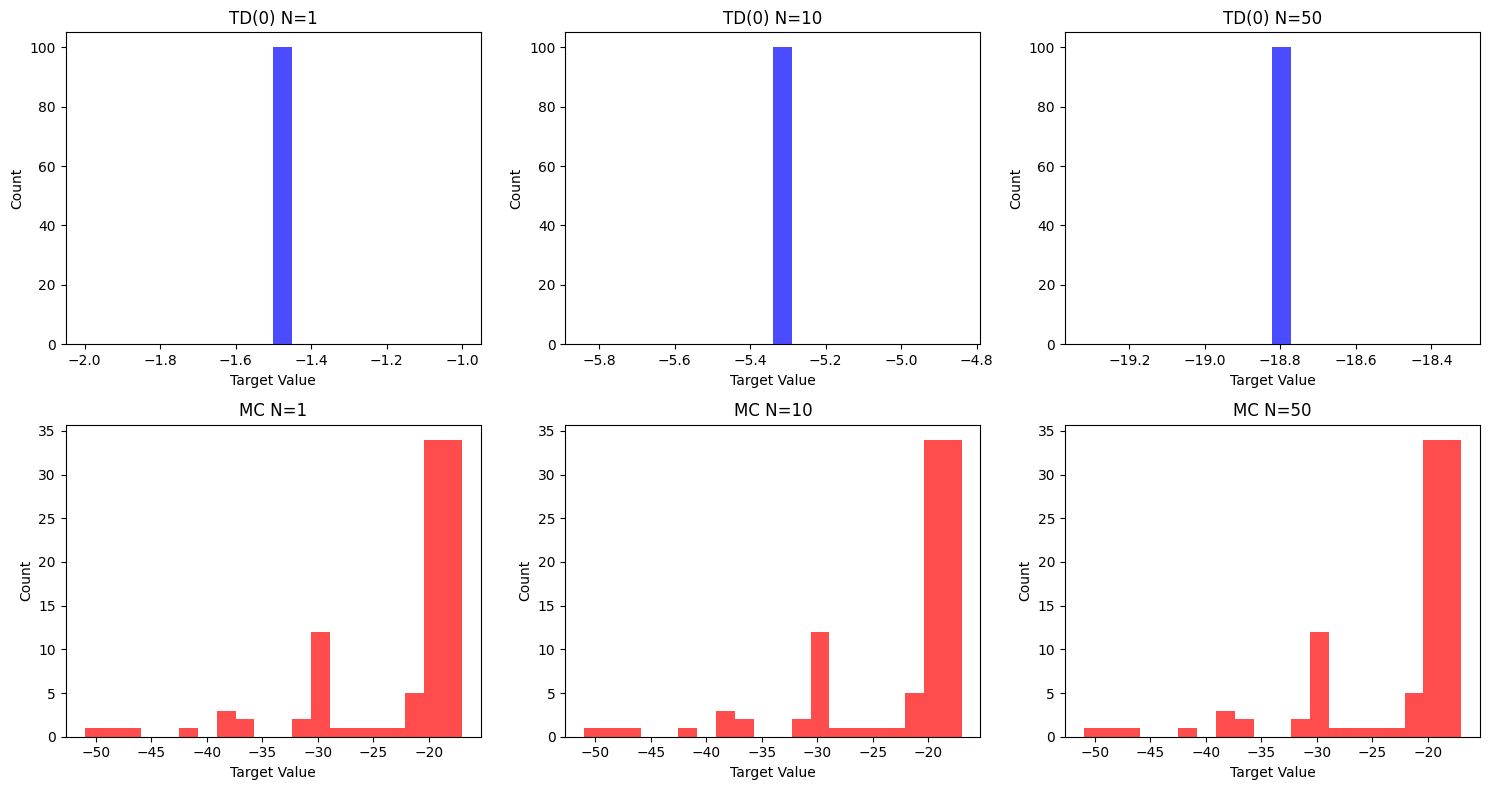

In [65]:
if __name__ == "__main__":
    np.random.seed(1234)
    random.seed(1234)
    run_on_policy_mc_td_epsilon_greedy_windy_gridworld()